# User Study — Qualitative Results

Companion notebook to `plots.ipynb`. It turns the qualitative synthesis in
`docs/results.md` (moderated think-aloud sessions + comparative interviews,
n=7) into thesis-ready artefacts, and triangulates them with the Likert data
in `data/appA.csv` / `data/appB.csv`.

Each artefact lives in its own cell:

| # | Artefact | Kind | Output name |
|---|---|---|---|
| 1 | Overall preference (App A / App B / Split) | bar chart | `overall_preference` |
| 2 | Thematic frequency across participants | table | `thematic_frequency` |
| 3 | Strengths & weaknesses per app | table | `strengths_weaknesses_app_a`, `..._app_b` |
| 4 | Representative participant quotes | callout boxes | `representative_quotes` |
| 5 | Likert difference per item (App B − App A) | bar chart | `likert_delta` |
| 6 | Quantitative ↔ qualitative triangulation | table | `triangulation` |

Charts are saved twice, exactly like in `plots.ipynb`:

- **PDF** → `output/figures/` (for quick viewing)
- **TikZ / PGFPlots `.tex`** → `output/tikz/` (for `\input{}` into the thesis)

Tables and quote boxes are LaTeX fragments → `output/tables/`, also meant to
be `\input{}`. Required packages: `booktabs`, `tabularx` (tables) and
`tcolorbox` (quote boxes, see the generated `quotebox_preamble.tex`). The
German quotes are written as UTF-8, so the thesis needs `utf8` `inputenc`
(the default since 2018) or a Unicode engine such as `lualatex`.

**Provenance.** All participant codings below are taken from
`docs/results.md` and use anonymised labels P1–P7. Only themes for which the
summary names concrete participants are counted; statements phrased as
"most"/"several" participants are discussed in prose instead, since they
cannot be turned into a defensible count. Quote texts are the participants'
verbatim survey free-text answers from the CSVs, unless marked otherwise.

Run all cells top to bottom (`Run All`) to (re-)generate every artefact.

In [1]:
import re
import matplotlib.pyplot as plt
import pandas as pd
import tikzplotlib
from pathlib import Path

%matplotlib inline

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "results" / "form-results"
FIGURES_DIR = PROJECT_ROOT / "output" / "figures"
TIKZ_DIR = PROJECT_ROOT / "output" / "tikz"
TABLES_DIR = PROJECT_ROOT / "output" / "tables"
for directory in (FIGURES_DIR, TIKZ_DIR, TABLES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

N_PARTICIPANTS = 7

# The CSVs identify participants by their initials, docs/results.md by the
# same Teilnehmer-ID. Quotes are keyed by those initials so a quote can be
# traced back to its CSV row, but only the P1-P7 labels are ever published.
PARTICIPANT_LABELS = {
    "MR": "P1", "MK": "P2", "AS": "P3", "JA": "P4",
    "HO": "P5", "TA": "P6", "MT": "P7",
}

# Same app colours as in plots.ipynb, so both notebooks' figures match.
APP_A_COLOR = "#764ba2"
APP_B_COLOR = "#ff3a0d"
SPLIT_COLOR = "#8a8a8a"

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# pgfplots closes the axis with a full box, while the rcParams above hide the
# top and right spine: pass these keys to save_figure so the exported .tex
# shows the same open L-frame as the PDF.
OPEN_FRAME_AXIS = ("axis x line=bottom", "axis y line=left", "axis line style={-}")

# tikzplotlib only LaTeX-escapes axis titles/labels/ticklabels, not plain
# ax.text() content (e.g. our "+1.14" bar labels). A bare "%" or "&" in a
# \node{...} silently breaks the .tex file, so escape those ourselves inside
# the `]{...};` node-text blocks tikzplotlib emits for ax.text() calls.
_TIKZ_NODE_TEXT_RE = re.compile(r"(\]\{)([^{}]*)(\};)")
_TIKZ_SPECIAL_CHARS = {"%": r"\%", "&": r"\&", "#": r"\#", "_": r"\_"}


def _escape_tikz_node_text(text):
    for char, escaped in _TIKZ_SPECIAL_CHARS.items():
        text = re.sub(rf"(?<!\\){re.escape(char)}", escaped, text)
    return text


def _sanitize_tikz_code(tikz_code):
    return _TIKZ_NODE_TEXT_RE.sub(
        lambda m: f"{m.group(1)}{_escape_tikz_node_text(m.group(2))}{m.group(3)}",
        tikz_code,
    )


# tikzplotlib turns a matplotlib font size into a node "scale" relative to a
# 20pt base, so a 9.5pt data label is exported at scale 0.475 and ends up at
# roughly 5pt in an 11pt document - unreadable. Raise the scale floor for
# those nodes; the PDF keeps the size that looks right on screen.
_TIKZ_NODE_SCALE_RE = re.compile(r"(node\[\s*\n\s*scale=)([0-9.]+)")


def _raise_node_scales(tikz_code, min_scale):
    return _TIKZ_NODE_SCALE_RE.sub(
        lambda m: f"{m.group(1)}{max(float(m.group(2)), min_scale):g}", tikz_code
    )


def _insert_axis_options(tikz_code, options):
    """Splice pgfplots axis keys into the exported axis, in the given order.

    Not via tikzplotlib's extra_axis_parameters: that is a set, so the keys
    come out in arbitrary order, and pgfplots keys are order-sensitive -
    "axis x line=bottom" resets the axis line style, which puts the arrow tip
    back on the axis if it happens to land after "axis line style={-}".
    """
    if not options:
        return tikz_code
    keys = "".join(f"{option},\n" for option in options)
    return tikz_code.replace("clip=false,\n", f"clip=false,\n{keys}", 1)


def save_figure(fig, name, width_slack_pt=None, min_node_scale=None, axis_options=()):
    """Save a figure as a standalone PDF and as a TikZ/PGFPlots .tex file.

    Both go to output/figures/<name>.pdf and output/tikz/<name>.tex, the
    latter ready for \\input{output/tikz/<name>.tex}. The axis is exported at
    width=\\linewidth with a height that keeps the figure's own aspect ratio,
    so one file fits any container (subfigure column, minipage, full page)
    without \\resizebox.

    width_slack_pt shrinks that width by a fixed amount. pgfplots does not
    account for long y-tick labels when it computes the bounding box, so a
    chart with wide row labels overflows the text block by roughly the label
    width; subtracting it keeps the final box at \\linewidth. The value is
    tuned against a real LaTeX run, not guessed from the PDF.

    min_node_scale is the smallest scale factor allowed for exported
    ax.text() nodes (see _raise_node_scales); pass it for charts whose data
    labels have to stay readable in the thesis.

    axis_options are pgfplots axis keys added to the exported axis. They are
    needed wherever tikzplotlib does not carry a matplotlib setting over:
    hidden spines (pgfplots draws a full box by default) and explicit tick
    positions (pgfplots otherwise picks its own, which come out crowded at
    the narrower exported width).
    """
    pdf_path = FIGURES_DIR / f"{name}.pdf"
    tex_path = TIKZ_DIR / f"{name}.tex"
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

    fig_width_in, fig_height_in = fig.get_size_inches()
    tikz_code = tikzplotlib.get_tikz_code(
        figure=fig,
        axis_width=r"\linewidth",
        axis_height=f"{fig_height_in / fig_width_in:.4f}\\linewidth",
        extra_axis_parameters={"clip=false"},
    )
    tikz_code = _insert_axis_options(tikz_code, axis_options)
    tikz_code = _sanitize_tikz_code(tikz_code)
    if min_node_scale is not None:
        tikz_code = _raise_node_scales(tikz_code, min_node_scale)
    if width_slack_pt is not None:
        tikz_code = tikz_code.replace(
            r"width=\linewidth",
            rf"width=\dimexpr\linewidth-{width_slack_pt}pt\relax",
        )
    tex_path.write_text(tikz_code)
    print(f"Saved {pdf_path.relative_to(PROJECT_ROOT)} and {tex_path.relative_to(PROJECT_ROOT)}")


_TEXT_ESCAPES = {
    "\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$",
    "#": r"\#", "_": r"\_", "{": r"\{", "}": r"\}",
    "~": r"\textasciitilde{}", "^": r"\textasciicircum{}",
}


def latex_text(text):
    """Escape prose for LaTeX and turn "quoted terms" into TeX quotes.

    Participants' answers contain quoted UI labels such as "Default"; a
    straight ASCII double quote renders as two right-hand quotes in LaTeX,
    so map those to a proper single-quote pair instead. German answers keep
    their umlauts, which need utf8 inputenc (the default since 2018) or a
    Unicode engine such as lualatex.
    """
    escaped = "".join(_TEXT_ESCAPES.get(char, char) for char in str(text))
    return re.sub(r'"([^"]*)"', r"`\1'", escaped)


def latex_quoted(text):
    """Wrap prose in TeX double quotes.

    A thin space saves the case where the quote itself ends on a quoted UI
    label: without it, the inner closing ' and the outer '' collide into
    three apostrophes, which TeX sets as a double quote plus a stray single
    one.
    """
    quoted = latex_text(text)
    separator = r"\," if quoted.endswith("'") else ""
    return f"``{quoted}{separator}''"


GENERATED_BY = "% Generated by notebooks/qualitative.ipynb - do not edit by hand."


def x_column(weight=1.0, align="raggedright"):
    """A tabularx X column of a given relative width.

    Left to itself, tabularx gives every X column the same share and sizes
    the fixed columns around their widest cell, which squeezes a theme
    column down to a few characters next to a column of participant lists.
    Weights fix the proportions; they have to sum to the number of X
    columns in the table, otherwise the total width drifts off \\linewidth.

    Prose is set ragged right: justifying it in a narrow column stretches
    the interword space badly and floods the log with underfull \\hbox
    warnings.
    """
    return rf">{{\{align}\arraybackslash\hsize={weight}\hsize}}X"


def save_table(latex_code, name, requires="booktabs, tabularx"):
    """Write a LaTeX fragment to output/tables/<name>.tex."""
    tex_path = TABLES_DIR / f"{name}.tex"
    header = f"{GENERATED_BY}\n% Requires: {requires}\n"
    tex_path.write_text(f"{header}{latex_code.strip()}\n")
    print(f"Saved {tex_path.relative_to(PROJECT_ROOT)}")

## 1. Overall Preference

Which app each participant preferred overall (`docs/results.md`, Section 1).
The single clearest number in the dataset, so it gets a standalone figure.

Saved output/figures/overall_preference.pdf and output/tikz/overall_preference.tex
App A: 1/7 (P2)
App B: 5/7 (P1, P3, P4, P6, P7)
Split: 1/7 (P5)


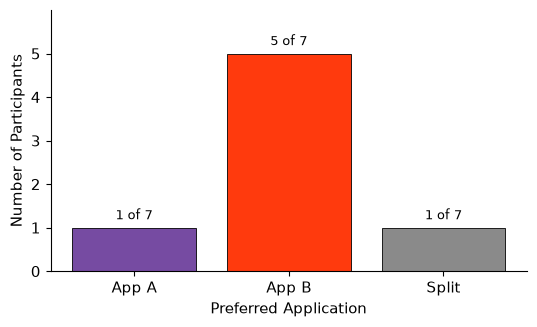

In [2]:
# Participant 6 answered "leaning App B" and is counted as App B, matching the
# tally in the results summary. Participant 5 split the decision: UI -> App A,
# answer quality -> App B.
PREFERENCE = {
    "App A": ["P2"],
    "App B": ["P1", "P3", "P4", "P6", "P7"],
    "Split": ["P5"],
}
PREFERENCE_COLORS = {"App A": APP_A_COLOR, "App B": APP_B_COLOR, "Split": SPLIT_COLOR}

choices = list(PREFERENCE)
counts = [len(PREFERENCE[choice]) for choice in choices]
colors = [PREFERENCE_COLORS[choice] for choice in choices]

fig, ax = plt.subplots(figsize=(5.5, 3.4))
bars = ax.bar(choices, counts, color=colors, edgecolor="black", linewidth=0.6)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 0.12,
            f"{count} of {N_PARTICIPANTS}", ha="center", va="bottom", fontsize=9.5)

ax.set_ylabel("Number of Participants")
ax.set_xlabel("Preferred Application")
ax.set_ylim(0, max(counts) + 1)
ax.set_yticks(range(0, max(counts) + 1))
fig.tight_layout()
save_figure(fig, "overall_preference", min_node_scale=0.8, axis_options=OPEN_FRAME_AXIS)

for choice, participants in PREFERENCE.items():
    print(f"{choice}: {len(participants)}/{N_PARTICIPANTS} ({', '.join(participants)})")

## 2. Thematic Frequency

How many of the 7 participants raised each recurring **parent opinion**, per
app (`docs/results.md`, Section 2). Near-duplicate phrases from the coding
log (e.g. multi-level structure and the long path to first chat) are merged
into one row so the table emphasises findings, not wording variants.

Deliberately a **table, not a chart**: with n=7, bars would suggest
statistical power that this sample does not have, while a frequency table is
the expected way to show recurring patterns in qualitative work.

Valence marks whether a theme was raised as a strength (+) or as a problem
(−). A dash means no participant raised the theme for that app.

In [3]:
# Parent opinions for the frequency table and theme matrix.
# (category, valence, theme, short label, participants for App A, for App B)
# Collapsed from the fine coding in docs/results.md Section 2: near-duplicate
# phrases that support the same finding share one row (union of participants).
# Contrasting takes (e.g. assertive vs soft tone) stay separate on purpose.
# The short label is the single-line version drawn next to the grid in 2.1;
# the table keeps the full text. Labels use 'single' quotes: matplotlib shows
# them as-is, and LaTeX sets them correctly without latex_text() quote rewriting.
PARENT_THEMES = [
    ("Onboarding & Navigation", "-",
     "Deep hierarchy / long path before the first useful chat",
     "Deep hierarchy / long path to first chat",
     ["P2", "P7"], []),
    ("Onboarding & Navigation", "-",
     "Manual Process step required before chatting (plus redundant workspace controls)",
     "Setup: Process required before chatting",
     ["P1", "P2", "P3", "P5", "P6", "P7"], []),
    ("Onboarding & Navigation", "+",
     "Familiar, ChatGPT-like interface lowers the learning curve",
     "Familiar ChatGPT-like interface",
     [], ["P1", "P2", "P3", "P7"]),
    ("Onboarding & Navigation", "-",
     "Chat-list / conversation management friction (auto-named Default, unclear multi-chat nav, upload-before-chat)",
     "Chat-list / conversation management friction",
     [], ["P2", "P4", "P5", "P7"]),
    ("Visual Design & Layout", "+",
     "Layout perceived as tidy and easy on the eye",
     "Tidy layout, easy on the eye",
     ["P5", "P6"], []),
    ("Visual Design & Layout", "-",
     "Visual style rejected outright (gradient, misaligned elements)",
     "Visual style rejected outright",
     ["P4"], []),
    ("Visual Design & Layout", "-",
     "Chat window opens scrolled to the bottom",
     "Chat opens scrolled to the bottom",
     ["P1", "P3"], []),
    ("Visual Design & Layout", "-",
     "Layout / visual polish issues (whitespace, font size, sidebar)",
     "Layout / visual polish issues",
     [], ["P2", "P4", "P6"]),
    ("Documents & Sources", "-",
     "Only one document at a time despite drag-and-drop",
     "One document at a time only",
     ["P5", "P6"], ["P5", "P6"]),
    ("Documents & Sources", "+",
     "Granular source citations appreciated (paragraph-level or section links)",
     "Granular source citations valued",
     ["P4"], ["P4", "P6"]),
    ("Answers & Response Style", "+",
     "Handles gaps safely: asks for context instead of hallucinating; out-of-scope questions answered transparently",
     "Safe handling of missing / out-of-scope context",
     ["P3", "P6"], ["P6"]),
    ("Answers & Response Style", "+",
     "Assertive recommendations preferred in a work context",
     "Assertive recommendations preferred",
     [], ["P3"]),
    ("Answers & Response Style", "-",
     "Tone too soft and hand-holding for professional use",
     "Tone too soft / hand-holding",
     [], ["P4"]),
    ("Answers & Response Style", "-",
     "No explanation why no answer could be found",
     "No explanation when no answer found",
     [], ["P1"]),
    ("General Impressions", "-",
     "App needs fine-tuning",
     "Needs fine-tuning",
     ["P2", "P6"], ["P2", "P6"]),
    ("General Impressions", "+",
     "Richer feature set, more possibilities for power users",
     "Richer feature set for power users",
     ["P6"], []),
]

VALENCE_SYMBOLS = {"+": "+", "-": "\u2212"}
NOT_MENTIONED = "\u2013"
NOT_MENTIONED_TEX = "--"


def format_mentions(participants, dash=NOT_MENTIONED):
    if not participants:
        return dash
    return f"{len(participants)} ({', '.join(participants)})"


theme_frequency = pd.DataFrame(
    [
        {
            "Category": category,
            "Theme": theme,
            "Valence": VALENCE_SYMBOLS[valence],
            "App A": format_mentions(app_a),
            "App B": format_mentions(app_b),
        }
        for category, valence, theme, _label, app_a, app_b in PARENT_THEMES
    ]
)
display(theme_frequency)


def build_frequency_table(records):
    mention_column = x_column(0.75, "centering")
    column_spec = f"@{{}}{x_column(1.5)}c{mention_column}{mention_column}@{{}}"
    rows = [
        rf"\begin{{tabularx}}{{\linewidth}}{{{column_spec}}}",
        r"\toprule",
        r"\textbf{Theme} & \textbf{Val.} & \textbf{App A} & \textbf{App B} \\",
    ]
    for category in dict.fromkeys(category for category, *_ in records):
        rows.append(r"\midrule")
        rows.append(rf"\multicolumn{{4}}{{@{{}}l}}{{\textit{{{latex_text(category)}}}}} \\")
        rows.append(r"\addlinespace[2pt]")
        for row_category, valence, theme, _label, app_a, app_b in records:
            if row_category != category:
                continue
            cells = [
                latex_text(theme),
                f"${valence}$",
                latex_text(format_mentions(app_a, NOT_MENTIONED_TEX)),
                latex_text(format_mentions(app_b, NOT_MENTIONED_TEX)),
            ]
            rows.append(" & ".join(cells) + r" \\")
    rows += [r"\bottomrule", r"\end{tabularx}"]
    # Parent opinions in 5 groups: \small keeps the table on a single page at
    # typical thesis text widths (tabularx cannot break across pages).
    return "\n".join([r"{\small", *rows, r"}"])


save_table(build_frequency_table(PARENT_THEMES), "thematic_frequency")


,Category,Theme,Valence,App A,App B
0,Onboarding & Navigation,Deep hierarchy / long path before the first us...,−,"2 (P2, P7)",–
1,Onboarding & Navigation,Manual Process step required before chatting (...,−,"6 (P1, P2, P3, P5, P6, P7)",–
2,Onboarding & Navigation,"Familiar, ChatGPT-like interface lowers the le...",+,–,"4 (P1, P2, P3, P7)"
3,Onboarding & Navigation,Chat-list / conversation management friction (...,−,–,"4 (P2, P4, P5, P7)"
4,Visual Design & Layout,Layout perceived as tidy and easy on the eye,+,"2 (P5, P6)",–
5,Visual Design & Layout,"Visual style rejected outright (gradient, misa...",−,1 (P4),–
6,Visual Design & Layout,Chat window opens scrolled to the bottom,−,"2 (P1, P3)",–
7,Visual Design & Layout,"Layout / visual polish issues (whitespace, fon...",−,–,"3 (P2, P4, P6)"
8,Documents & Sources,Only one document at a time despite drag-and-drop,−,"2 (P5, P6)","2 (P5, P6)"
9,Documents & Sources,Granular source citations appreciated (paragra...,+,1 (P4),"2 (P4, P6)"


Saved output/tables/thematic_frequency.tex


### 2.1 Theme × Participant Matrix

The same parent opinions as the table above, drawn as a grid: one row per
finding, one column per participant. A marker means that participant raised
the opinion for that app — colour encodes the app (purple = App A, red =
App B), shape the valence (square = complaint, circle = praise). Where a
participant raised the same opinion for both apps, the two markers sit side
by side. Rows are shortened to their gist; the full wording is in the table
above.

The grid makes concentration visible that a count table hides: App A's
onboarding complaints cluster on setup ceremony and hierarchy depth, while
App B's complaints gather on chat-list management and visual polish — and
both apps collect praise in document handling and answer quality, not in
onboarding.


Saved output/figures/theme_matrix.pdf and output/tikz/theme_matrix.tex


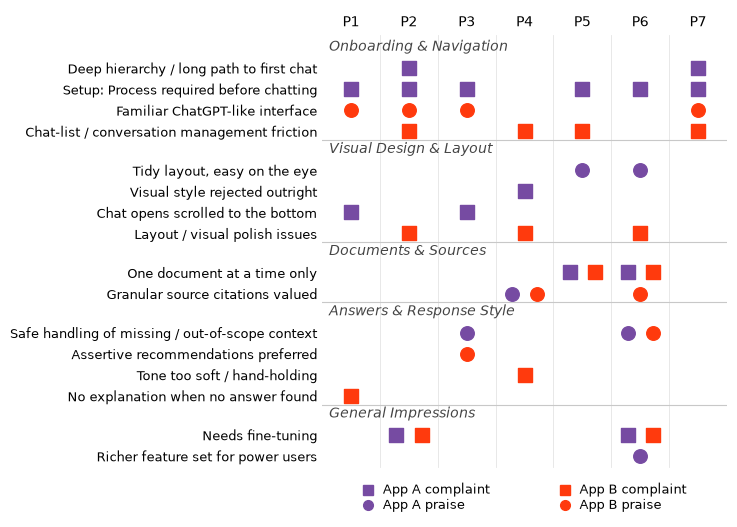

In [4]:
PARTICIPANT_COLUMNS = [f"P{i}" for i in range(1, N_PARTICIPANTS + 1)]

# Flatten parent opinions into grid rows; category headers sit on the gap
# row between groups, like the \multicolumn rows in the table above.
GROUP_GAP = 0.85
grid_rows = []      # (y, label, valence, app_a, app_b)
category_rows = []  # (y, category)
y = 0.0
for group_index, category in enumerate(dict.fromkeys(c for c, *_ in PARENT_THEMES)):
    if group_index:
        y -= GROUP_GAP
    category_rows.append((y, category))
    for row_category, valence, _theme, label, app_a, app_b in PARENT_THEMES:
        if row_category != category:
            continue
        y -= 1.0
        grid_rows.append((y, label, valence, app_a, app_b))

VALENCE_MARKERS = {"+": "o", "-": "s"}
BOTH_OFFSET = 0.22

# One scatter call per (shape, colour, offset) combo: tikzplotlib exports
# every scatter call as its own \addplot, so batching keeps the .tex small.
marks = {}
for row_y, _label, valence, app_a, app_b in grid_rows:
    for app_color, participants in ((APP_A_COLOR, app_a), (APP_B_COLOR, app_b)):
        for participant in participants:
            x = PARTICIPANT_COLUMNS.index(participant) + 1
            in_both = participant in app_a and participant in app_b
            offset = 0.0
            if in_both:
                offset = -BOTH_OFFSET if app_color == APP_A_COLOR else BOTH_OFFSET
            key = (VALENCE_MARKERS[valence], app_color)
            marks.setdefault(key, []).append((x + offset, row_y))

fig, ax = plt.subplots(figsize=(7.5, 5.4))
top_y = 0.55
bottom_y = grid_rows[-1][0] - 0.55

# Column guides and group separators first, so the markers draw on top.
for x in (1.5, 2.5, 3.5, 4.5, 5.5, 6.5):
    ax.plot([x, x], [bottom_y, top_y], color="#e4e4e4", lw=0.6, zorder=1)
for gap_y, _category in category_rows[1:]:
    ax.axhline(gap_y + GROUP_GAP / 2, color="#c8c8c8", lw=0.8, zorder=1)

for (marker, color), points in marks.items():
    xs, ys = zip(*points)
    ax.scatter(xs, ys, marker=marker, s=95, color=color, zorder=3)

for column, participant in enumerate(PARTICIPANT_COLUMNS, start=1):
    ax.text(column, top_y + 0.6, participant, ha="center", va="center", fontsize=10)
for gap_y, category in category_rows:
    ax.text(0.62, gap_y, category, ha="left", va="center",
            fontsize=10, fontstyle="italic", color="#444444")

ax.set_yticks([row_y for row_y, *_ in grid_rows])
ax.set_yticklabels([label for _y, label, *_ in grid_rows], fontsize=9.5)
ax.set_xlim(0.5, N_PARTICIPANTS + 0.5)
ax.set_ylim(bottom_y - 2.35, top_y + 1.2)
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

# Legend in plain data coordinates, like the axis annotations in the other
# cells: fig.legend() does not survive the tikzplotlib export, and a 4-wide
# legend row would overflow once the exported axis shrinks to \linewidth
# minus the label slack, so the four combos go into two rows of two.
# The markers are single-point ax.plot calls, not scatter: tikzplotlib
# exports a one-point PathCollection as the raw marker outline placed near
# the axis origin instead of at the data point, but a one-point line plot
# comes out as a properly positioned \addplot ... only marks.
legend_rows = [
    (bottom_y - 1.05, [("s", APP_A_COLOR, "App A complaint"), ("s", APP_B_COLOR, "App B complaint")]),
    (bottom_y - 1.8, [("o", APP_A_COLOR, "App A praise"), ("o", APP_B_COLOR, "App B praise")]),
]
for legend_y, items in legend_rows:
    for legend_x, (marker, color, text) in zip((1.3, 4.7), items):
        ax.plot([legend_x], [legend_y], marker=marker, color=color,
                linestyle="none", markersize=7, zorder=3)
        ax.text(legend_x + 0.25, legend_y, text, ha="left", va="center", fontsize=9)

fig.tight_layout()
# Same bounding-box problem as the Likert delta chart: pgfplots does not
# reserve room for the row labels on the left, so hand that width back (the
# value is tuned against a real LaTeX run). The grid floats free with no
# frame or tick marks, so both axis lines and the y ticks stay hidden as in
# the PDF. tikzplotlib also drops the smaller yticklabel font size, so that
# one is repeated as a pgfplots key.
save_figure(
    fig,
    "theme_matrix",
    width_slack_pt=165,
    min_node_scale=0.8,
    axis_options=(
        "x axis line style={draw=none}",
        "y axis line style={draw=none}",
        "xtick style={draw=none}",
        "ytick style={draw=none}",
        r"yticklabel style={font=\footnotesize}",
    ),
)


## 3. Strengths & Weaknesses per App

Two-column summaries condensed from `docs/results.md`, Section 2 — meant to
be scannable in half a minute in a results subsection. Strengths and
weaknesses are independent lists, so the pairing across a row carries no
meaning; the shorter column is padded with blanks.

In [5]:
STRENGTHS_WEAKNESSES = {
    "App A": {
        "strengths": [
            "Tidy, well-organised button styling and colouring (P5, P6)",
            "Richer feature set: workspaces, multi-document projects, compare, rename/delete (P6)",
            "Paragraph-level source highlighting and hover tooltips build trust (P4)",
            "Cautious, factual phrasing; asks for context instead of guessing (P3, P4)",
        ],
        "weaknesses": [
            "Manual \"Process\" step before uploaded documents can be used (P1, P2, P3, P5, P6, P7)",
            "\"New Workspace\" vs. \"Create Workspace\" perceived as redundant (P1, P3, P6, P7)",
            "Workspaces/Chats/Threads hierarchy causes disorientation (P2, P7)",
            "Long path to the first chat: roughly 18 steps, \"terribly complicated\" (P7)",
            "Chat window opens scrolled to the bottom (P1, P3)",
            "Visual style rejected outright: gradient, misaligned elements (P4)",
            "Bugs: JSON parse error, stuck loading bar, drag-and-drop limits (P4, P5, P6)",
        ],
    },
    "App B": {
        "strengths": [
            "Familiar, ChatGPT-like interface lowers the learning curve (P1, P2, P3, P7)",
            "Read as finished rather than prototype-like, with better-structured answers (P3)",
            "Minimalistic layout, less clicking to reach an answer (P1)",
            "Assertive recommendations (\"should\" instead of \"could\") fit a work context (P3)",
            "Citations link directly to specific document sections (P4, P6)",
        ],
        "weaknesses": [
            "Conversations auto-named \"Default\"; renaming not discoverable (P2, P4, P5, P7)",
            "Whitespace and content width problems: too much empty space, or too wide (P4, P6)",
            "Small font size and cramped chat input area (P2)",
            "Left sidebar visually cut off and misaligned (P6)",
            "Upload required before any chat interaction in several flows (P7)",
            "Navigation unclear once several chats exist (P2)",
            "Tone too soft and hand-holding for a professional context (P4)",
            "No explanation why no answer was found (P1); consent/consensus slip (P4)",
        ],
    },
}


def build_strengths_weaknesses_table(app, strengths, weaknesses):
    rows = [
        rf"\begin{{tabularx}}{{\linewidth}}{{@{{}}{x_column()}{x_column()}@{{}}}}",
        r"\toprule",
        rf"\multicolumn{{2}}{{@{{}}l}}{{\textbf{{{latex_text(app)}}}}} \\",
        r"\midrule",
        r"\textbf{Strengths} & \textbf{Weaknesses} \\",
        r"\midrule",
    ]
    padded = zip(
        strengths + [""] * max(0, len(weaknesses) - len(strengths)),
        weaknesses + [""] * max(0, len(strengths) - len(weaknesses)),
    )
    for strength, weakness in padded:
        rows.append(rf"{latex_text(strength)} & {latex_text(weakness)} \\")
        rows.append(r"\addlinespace[3pt]")
    rows += [r"\bottomrule", r"\end{tabularx}"]
    return "\n".join(rows)


for app, entries in STRENGTHS_WEAKNESSES.items():
    display(pd.DataFrame({
        f"{app} — Strengths": pd.Series(entries["strengths"]),
        f"{app} — Weaknesses": pd.Series(entries["weaknesses"]),
    }).fillna(""))
    save_table(
        build_strengths_weaknesses_table(app, entries["strengths"], entries["weaknesses"]),
        f"strengths_weaknesses_{app.lower().replace(' ', '_')}",
    )

,App A — Strengths,App A — Weaknesses
0,"Tidy, well-organised button styling and colour...","Manual ""Process"" step before uploaded document..."
1,"Richer feature set: workspaces, multi-document...","""New Workspace"" vs. ""Create Workspace"" perceiv..."
2,Paragraph-level source highlighting and hover ...,Workspaces/Chats/Threads hierarchy causes diso...
3,"Cautious, factual phrasing; asks for context i...","Long path to the first chat: roughly 18 steps,..."
4,,"Chat window opens scrolled to the bottom (P1, P3)"
5,,"Visual style rejected outright: gradient, misa..."
6,,"Bugs: JSON parse error, stuck loading bar, dra..."


Saved output/tables/strengths_weaknesses_app_a.tex


,App B — Strengths,App B — Weaknesses
0,"Familiar, ChatGPT-like interface lowers the le...","Conversations auto-named ""Default""; renaming n..."
1,"Read as finished rather than prototype-like, w...",Whitespace and content width problems: too muc...
2,"Minimalistic layout, less clicking to reach an...",Small font size and cramped chat input area (P2)
3,"Assertive recommendations (""should"" instead of...",Left sidebar visually cut off and misaligned (P6)
4,Citations link directly to specific document s...,Upload required before any chat interaction in...
5,,Navigation unclear once several chats exist (P2)
6,,Tone too soft and hand-holding for a professio...
7,,No explanation why no answer was found (P1); c...


Saved output/tables/strengths_weaknesses_app_b.tex


## 4. Representative Quotes

Pull-quote boxes to place next to the theme they illustrate. German answers
keep the original wording with an English translation underneath, so the
reader can check the interpretation.

Two entries are marked as *not verbatim*: they summarise moderator notes
from the think-aloud sessions rather than a written answer, and are therefore
rendered without quotation marks. Add further quotes from the raw interview
notes by appending to `QUOTES` — anything with `verbatim=False` is typeset as
a summary rather than as a citation.

The generated `representative_quotes.tex` uses a `quotebox` environment; the
matching definition is written to `output/tables/quotebox_preamble.tex` for
the thesis preamble (needs `\usepackage[most]{tcolorbox}`).

In [6]:
# Entries are keyed by the participant's CSV initials so a quote can be traced
# back to its row; only the P1-P7 label reaches the generated LaTeX.
# source: where the wording comes from - the written survey free text
# (data/appA.csv, data/appB.csv, columns "Was hat dir am besten gefallen?" /
# "Was hat dich gestoert?" / "Sonstige Anmerkungen") or the moderator's
# session notes as synthesised in docs/results.md.
QUOTES = [
    {
        "initials": "MT", "app": "App A", "theme": "Onboarding & Navigation",
        "german": "zu kompliziert, Aufteilung in Workspaces/Threads unklar/unnötig. "
                  "Dateien müssen erst explizit \"processed\" werden, bevor sie verwendet werden können",
        "english": "too complicated, the split into workspaces/threads is unclear/unnecessary. "
                   "Files have to be explicitly \"processed\" first before they can be used",
        "verbatim": True, "source": "survey free text",
    },
    {
        "initials": "HO", "app": "App A", "theme": "Onboarding & Navigation",
        "german": "man musste noch \"process\" drücken, das ist glaube ich am anfang nicht "
                  "selbsterklärend, wird aber nach dem ersten versuch zu chatten klar",
        "english": "you still had to press \"process\", which I don't think is self-explanatory "
                   "at first, but it becomes clear after the first attempt to chat",
        "verbatim": True, "source": "survey free text",
    },
    {
        "initials": "JA", "app": "App A", "theme": "Visual Design & Layout",
        "german": None,
        "english": "terrible AI slop",
        "verbatim": True, "source": "interview, on the colour gradient and misaligned elements",
    },
    {
        "initials": "MK", "app": "App B", "theme": "Onboarding & Navigation",
        "german": "Chats werden nicht automatisch benannt; bei mehreren Chats ist es schwer "
                  "etwas zu finden wenn diese nur \"Default\" heißen",
        "english": "Chats are not named automatically; with several chats it is hard to find "
                   "anything when they are all just called \"Default\"",
        "verbatim": True, "source": "survey free text",
    },
    {
        "initials": "JA", "app": "App B", "theme": "Onboarding & Navigation",
        "german": "Es gab keine Überraschungen, look and feel entsprachen großteils "
                  "Branchenstandards. Das Layout war farblich gut gewählt.",
        "english": "There were no surprises, look and feel largely matched industry standards. "
                   "The layout's colours were well chosen.",
        "verbatim": True, "source": "survey free text",
    },
    {
        "initials": "JA", "app": "Both apps", "theme": "General Impressions",
        "german": None,
        "english": "Reflected on how strongly visual polish and workflow friction shaped his "
                   "overall judgement, even though the answer quality itself felt comparable "
                   "between the two apps.",
        "verbatim": False, "source": "session notes, docs/results.md Section 2.5",
    },
    {
        "initials": "HO", "app": "Both apps", "theme": "Overall Preference",
        "german": None,
        "english": "Split the decision: App A for the interface (\"nicer to look at\"), "
                   "App B for answer quality (\"better structured\").",
        "verbatim": False, "source": "session notes, docs/results.md Section 1",
    },
]

QUOTEBOX_PREAMBLE = r"""
\usepackage[most]{tcolorbox}

\newtcolorbox{quotebox}[1]{%
    colback=black!3, colframe=black!45, boxrule=0.4pt, sharp corners,
    left=6pt, right=6pt, top=5pt, bottom=5pt,
    before skip=8pt, after skip=8pt,
    fonttitle=\bfseries\small, title={#1}}
"""


def build_quote_box(quote):
    participant = PARTICIPANT_LABELS[quote["initials"]]
    title = " -- ".join([participant, quote["app"], quote["theme"]])
    body = []
    if quote["german"]:
        body.append(rf"\textit{{{latex_quoted(quote['german'])}}}\\[3pt]")
        body.append(latex_quoted(quote["english"]))
    elif quote["verbatim"]:
        body.append(rf"\textit{{{latex_quoted(quote['english'])}}}")
    else:
        body.append(latex_text(quote["english"]))
    body.append(rf"\\[3pt]{{\footnotesize Source: {latex_text(quote['source'])}.}}")
    return "\n".join([
        rf"\begin{{quotebox}}{{{latex_text(title)}}}",
        *body,
        r"\end{quotebox}",
    ])


(TABLES_DIR / "quotebox_preamble.tex").write_text(
    f"{GENERATED_BY}\n{QUOTEBOX_PREAMBLE.strip()}\n"
)
print(f"Saved {(TABLES_DIR / 'quotebox_preamble.tex').relative_to(PROJECT_ROOT)}")

save_table(
    "\n\n".join(build_quote_box(quote) for quote in QUOTES),
    "representative_quotes",
    requires=r"tcolorbox (see quotebox_preamble.tex)",
)

for quote in QUOTES:
    marker = "verbatim" if quote["verbatim"] else "summary"
    participant = PARTICIPANT_LABELS[quote["initials"]]
    print(f"[{marker}] {participant} / {quote['app']}: {quote['english'][:80]}...")

Saved output/tables/quotebox_preamble.tex
Saved output/tables/representative_quotes.tex
[verbatim] P7 / App A: too complicated, the split into workspaces/threads is unclear/unnecessary. Files...
[verbatim] P5 / App A: you still had to press "process", which I don't think is self-explanatory at fir...
[verbatim] P4 / App A: terrible AI slop...
[verbatim] P2 / App B: Chats are not named automatically; with several chats it is hard to find anythin...
[verbatim] P4 / App B: There were no surprises, look and feel largely matched industry standards. The l...
[summary] P4 / Both apps: Reflected on how strongly visual polish and workflow friction shaped his overall...
[summary] P5 / Both apps: Split the decision: App A for the interface ("nicer to look at"), App B for answ...


## 5. Triangulation with the Likert Data

Mixed-methods framing: the quantitative result first, then the qualitative
explanation of *why*. Both artefacts below reuse the Likert answers from
`data/appA.csv` and `data/appB.csv` — the same source as the
`likert_comparison` chart in `plots.ipynb`.

In [7]:
# --- Load the Likert answers & map to numeric 1-5 (as in plots.ipynb) ---
LIKERT_COLS = list(range(4, 16)) + [19]

raw_a = pd.read_csv(DATA_DIR / "appA.csv", sep=";", encoding="utf-8").iloc[:, LIKERT_COLS]
raw_b = pd.read_csv(DATA_DIR / "appB.csv", sep=";", encoding="utf-8").iloc[:, LIKERT_COLS]

FIRST_IMPRESSION_MAP = {
    "sehr negativ": 1, "negativ": 2, "neutral": 3, "positiv": 4, "sehr positiv": 5,
}
AGREEMENT_MAP = {
    "stimme gar nicht zu": 1, "stimme nicht zu": 2, "weder noch": 3,
    "stimme zu": 4, "stimme voll zu": 5,
}
SATISFACTION_MAP = {
    "sehr unzufrieden": 1, "unzufrieden": 2, "neutral": 3,
    "zufrieden": 4, "sehr zufrieden": 5,
}


def parse_likert(series, col_idx):
    """Choose the right mapping: col 0 = first impression, col 12 = satisfaction."""
    if col_idx == 0:
        return series.map(FIRST_IMPRESSION_MAP)
    if col_idx == 12:
        return series.map(SATISFACTION_MAP)
    return series.map(AGREEMENT_MAP)


items = [
    "1.1 First Impression",
    "1.2 Professional Design",
    "2.1 Colour Consistency",
    "2.2 Font Readability",
    "2.3 Text Contrast",
    "2.4 Button Consistency",
    "2.5 Layout Cleanliness",
    "3.1 Ease of Use",
    "3.2 Navigation Clarity",
    "4.1 Answer Relevance",
    "4.2 Answer Correctness",
    "4.3 Edge-Case Handling",
    "6.1 Overall Satisfaction",
]

app_a = pd.DataFrame({i: parse_likert(raw_a.iloc[:, i], i) for i in range(len(items))})
app_b = pd.DataFrame({i: parse_likert(raw_b.iloc[:, i], i) for i in range(len(items))})
app_a.columns = items
app_b.columns = items

likert_means = pd.DataFrame({"App A": app_a.mean(), "App B": app_b.mean()})
likert_means["Difference"] = likert_means["App B"] - likert_means["App A"]
display(likert_means.round(2))

,App A,App B,Difference
1.1 First Impression,3.00,4.14,1.14
1.2 Professional Design,2.86,4.00,1.14
2.1 Colour Consistency,4.00,4.29,0.29
2.2 Font Readability,5.00,4.43,-0.57
2.3 Text Contrast,5.00,4.57,-0.43
2.4 Button Consistency,3.86,4.00,0.14
2.5 Layout Cleanliness,4.43,4.57,0.14
3.1 Ease of Use,3.29,4.29,1.00
3.2 Navigation Clarity,4.00,4.57,0.57
4.1 Answer Relevance,4.14,4.43,0.29


### 5.1 Likert Difference per Item

Per-item mean difference (App B − App A), sorted by size. This is the
quantitative half of the triangulation: it shows *where* the two apps
actually diverge, which is what the qualitative themes then explain.

Saved output/figures/likert_delta.pdf and output/tikz/likert_delta.tex


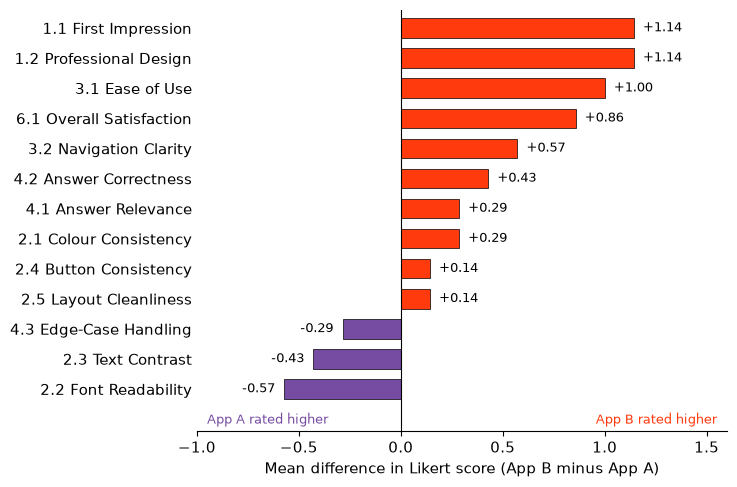

In [8]:
differences = likert_means["Difference"].sort_values()
bar_colors = [APP_B_COLOR if value > 0 else APP_A_COLOR for value in differences]

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.barh(differences.index, differences.values, color=bar_colors,
               edgecolor="black", linewidth=0.5, height=0.65)
ax.axvline(0, color="black", lw=0.8)

for bar, value in zip(bars, differences.values):
    offset = 0.045 if value >= 0 else -0.045
    ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f"{value:+.2f}",
            va="center", ha="left" if value >= 0 else "right", fontsize=9)

ax.set_xlabel("Mean difference in Likert score (App B minus App A)")
ax.set_xlim(-1.0, 1.6)
ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0, 1.5])
# Direction is the whole point of the chart, so name it on the axis itself
# instead of relying on a legend the reader has to map back onto the colours.
# The extra ylim headroom keeps both hints inside the exported bounding box.
ax.set_ylim(-1.4, len(differences) - 0.4)
ax.text(-0.95, -1.15, "App A rated higher", color=APP_A_COLOR, fontsize=9, ha="left")
ax.text(1.55, -1.15, "App B rated higher", color=APP_B_COLOR, fontsize=9, ha="right")
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
fig.tight_layout()
# Long item labels on the y-axis: pgfplots does not reserve room for them, so
# hand that width back (124pt is the smallest value that compiles without an
# overfull \hbox at \linewidth). The zero line carries the reference here, so
# the y-axis line and its tick marks stay hidden as in the PDF.
save_figure(
    fig,
    "likert_delta",
    width_slack_pt=124,
    min_node_scale=0.8,
    axis_options=(
        *OPEN_FRAME_AXIS,
        "y axis line style={draw=none}",
        "ytick style={draw=none}",
        "xtick={-1,-0.5,0,0.5,1,1.5}",
    ),
)

### 5.2 Quantitative ↔ Qualitative Triangulation

One row per Likert item worth discussing: the measured difference, the
qualitative explanation, and the section of `docs/results.md` it comes from.
The numbers are read out of the data rather than typed in, so the table
cannot drift away from the CSVs.

In [9]:
# (Likert item, qualitative explanation, source section in docs/results.md)
TRIANGULATION = [
    ("1.2 Professional Design",
     "App B read as finished and close to industry standards, while App A's colour gradient "
     "and misaligned elements were rejected outright as \"terrible AI slop\".",
     "2.2"),
    ("1.1 First Impression",
     "App B's familiar chat layout gave an immediate entry point; App A required understanding "
     "the workspace concept before anything could be done.",
     "2.1"),
    ("3.1 Ease of Use",
     "The largest usability gap: App A's mandatory manual \"Process\" step (6 of 7 participants) "
     "and the duplicate workspace buttons dominated the complaints.",
     "2.1"),
    ("3.2 Navigation Clarity",
     "App A's Workspaces/Chats/Threads hierarchy caused back-and-forth clicking. App B's flat "
     "chat list was clearer, but \"Default\" naming blurs it once several chats exist.",
     "2.1"),
    ("2.2 Font Readability",
     "One of the few items favouring App A: its typography and button styling were called tidy "
     "and easy on the eye, whereas App B's small font and cramped input area were criticised.",
     "2.2"),
    ("2.3 Text Contrast",
     "Also in App A's favour: its more organised colouring was appreciated, while App B's "
     "minimalism came across as visually thin (cut-off sidebar, excess whitespace).",
     "2.2"),
    ("4.1 Answer Relevance",
     "Near-parity, as expected: participants rated the underlying answers as broadly comparable "
     "and located the difference in workflow and presentation, not retrieval quality.",
     "2.4"),
    ("4.2 Answer Correctness",
     "Small edge for App B from its better-structured, more assertive answers; the one factual "
     "slip found in App B (consent- vs. consensus-based) was noticed by a single participant.",
     "2.3, 2.4"),
    ("4.3 Edge-Case Handling",
     "App A stated missing context and asked back instead of guessing, while App B answered the "
     "out-of-scope question without explaining why nothing was found.",
     "2.4"),
    ("6.1 Overall Satisfaction",
     "Mirrors the 5 of 7 preference for App B: comparable answer quality, markedly less "
     "workflow friction.",
     "1, 2.5"),
]

triangulation = pd.DataFrame(
    [
        {
            "Item": item,
            "App A": round(likert_means.loc[item, "App A"], 2),
            "App B": round(likert_means.loc[item, "App B"], 2),
            "Difference": round(likert_means.loc[item, "Difference"], 2),
            "Qualitative Explanation": explanation,
            "Ref.": section,
        }
        for item, explanation, section in TRIANGULATION
    ]
)
display(triangulation)


def build_triangulation_table(records):
    rows = [
        rf"\begin{{tabularx}}{{\linewidth}}{{@{{}}lcc{x_column()}c@{{}}}}",
        r"\toprule",
        r"\textbf{Likert item} & \textbf{A} & \textbf{B} & "
        r"\textbf{Qualitative explanation} & \textbf{Ref.} \\",
        r"\midrule",
    ]
    for item, explanation, section in records:
        means = likert_means.loc[item]
        cells = [
            latex_text(item),
            f"{means['App A']:.2f}",
            f"{means['App B']:.2f}",
            latex_text(explanation),
            latex_text(section),
        ]
        rows.append(" & ".join(cells) + r" \\")
        rows.append(r"\addlinespace[3pt]")
    rows += [
        r"\bottomrule",
        r"\multicolumn{5}{@{}l}{\footnotesize A/B = mean Likert score (1--5), n=7. "
        r"Ref. = section in the qualitative synthesis.} \\",
        r"\end{tabularx}",
    ]
    return "\n".join([r"{\small", *rows, r"}"])


save_table(build_triangulation_table(TRIANGULATION), "triangulation")

,Item,App A,App B,Difference,Qualitative Explanation,Ref.
0,1.2 Professional Design,2.86,4.00,1.14,App B read as finished and close to industry s...,2.2
1,1.1 First Impression,3.00,4.14,1.14,App B's familiar chat layout gave an immediate...,2.1
2,3.1 Ease of Use,3.29,4.29,1.00,The largest usability gap: App A's mandatory m...,2.1
3,3.2 Navigation Clarity,4.00,4.57,0.57,App A's Workspaces/Chats/Threads hierarchy cau...,2.1
4,2.2 Font Readability,5.00,4.43,-0.57,One of the few items favouring App A: its typo...,2.2
5,2.3 Text Contrast,5.00,4.57,-0.43,Also in App A's favour: its more organised col...,2.2
6,4.1 Answer Relevance,4.14,4.43,0.29,"Near-parity, as expected: participants rated t...",2.4
7,4.2 Answer Correctness,4.29,4.71,0.43,Small edge for App B from its better-structure...,"2.3, 2.4"
8,4.3 Edge-Case Handling,4.71,4.43,-0.29,App A stated missing context and asked back in...,2.4
9,6.1 Overall Satisfaction,3.29,4.14,0.86,Mirrors the 5 of 7 preference for App B: compa...,"1, 2.5"


Saved output/tables/triangulation.tex
